# Test isotherm fitting

Our strategy here is to generate data points that follow a given isotherm model, then fit an isotherm model to the data using pyIAST, and check that pyIAST identifies the parameters correctly.

In [1]:
import project_path
import pyiast
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

test


We test all analytical models implemented in pyIAST.

In [2]:
models = pyiast._MODELS
models

['Langmuir',
 'Quadratic',
 'BET',
 'Henry',
 'TemkinApprox',
 'DSLangmuir',
 'Freundlich']

This dictionary gives the model parameters for which we generate synthetic data to test pyIAST fitting. Note that, because the DSLF model has so many parameters, it is highly likely that such a model will overfit the data. Thus, we expect pyIAST to reach a local minimum for DSLF yet still obtain a reasonable fit with the default starting guess.

In [3]:
model_params = {
    "Fruendlicht": {"K": 10.0, "n_inv": 0.5},
    "Langmuir": {"M": 10.0, "K": 10.0},
    "Quadratic": {"M": 10.0, "Ka": 10.0, "Kb": 10.0 ** 2 * 3},
    "BET": {"M": 10.0, "Ka": 10.0, "Kb": .2},
    "DSLangmuir": {"M1": 10.0, "K1": 1.0,
                   "M2": 30.0, "K2": 30.0}, # warning: 1/2 is arbitrary
    "Henry": {"KH": 10.0},
    "TemkinApprox": {"M": 10.0, "K": 10.0, "theta": -0.1}
}

The loading function generates synthetic data for a given model. We pass it an array of pressures and it returns loading using the given model. Note that the parameters for each model are taken from the above dictionary.

In [4]:
def loading(P, model):
    """
    Return loading at pressure P using a given model.

    :param P: np.array array of pressures
    :param model: string specify model
    """
    if model not in models:
        raise Exception("This model is not implemented in the test suite.")

    if model == "Langmuir":
        M = model_params[model]["M"]
        K = model_params[model]["K"]
        return M * K * P / (1.0 + K * P)

    if model == "Quadratic":
        M = model_params[model]["M"]
        Ka = model_params[model]["Ka"]
        Kb = model_params[model]["Kb"]
        return M * P * (Ka + 2.0 * Kb * P) / (1.0 + Ka * P + Kb * P ** 2)

    if model == "BET":
        M = model_params[model]["M"]
        Ka = model_params[model]["Ka"]
        Kb = model_params[model]["Kb"]
        return M * Ka * P / (1.0 - Kb * P) / (1.0 - Kb * P + Ka * P)

    if model == "DSLangmuir":
        M1 = model_params[model]["M1"]
        K1 = model_params[model]["K1"]

        M2 = model_params[model]["M2"]
        K2 = model_params[model]["K2"]

        return M1 * K1 * P / (1.0 + K1 * P) +\
               M2 * K2 * P / (1.0 + K2 * P)

    if model == "TemkinApprox":
        M = model_params[model]["M"]
        K = model_params[model]["K"]
        theta = model_params[model]["theta"]

        fractional_langmuir_loading = K * P / (1.0 + K * P)
        return M * (fractional_langmuir_loading + theta *
                    fractional_langmuir_loading ** 2 *
                    (fractional_langmuir_loading - 1.0))

    if model == "Henry":
        return model_params[model]["KH"] * P

## Test model fits

Loop through all models, generate synthetic data using parameters in `model_params` and the `loading` function here, then fit model using pyIAST. Plot data and fits, check that pyIAST identified parameters match the model.

Testing model: Langmuir
Langmuir identified model parameters:
	M = 10.000000
	K = 10.000000
('RMSE = ', 1.287092809770968e-15)


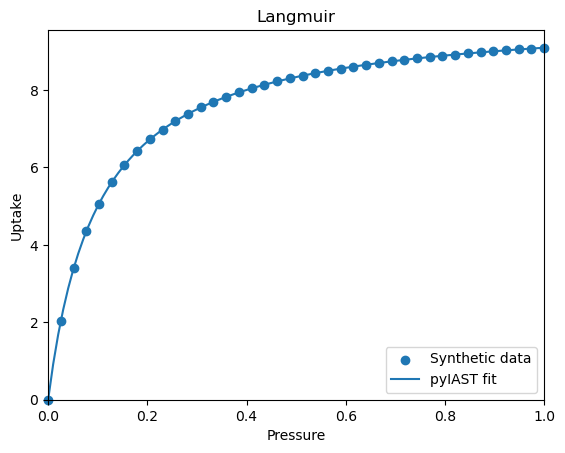

Testing model: Quadratic
Quadratic identified model parameters:
	M = 10.000000
	Ka = 10.000000
	Kb = 300.000000
('RMSE = ', 7.748052328638405e-15)


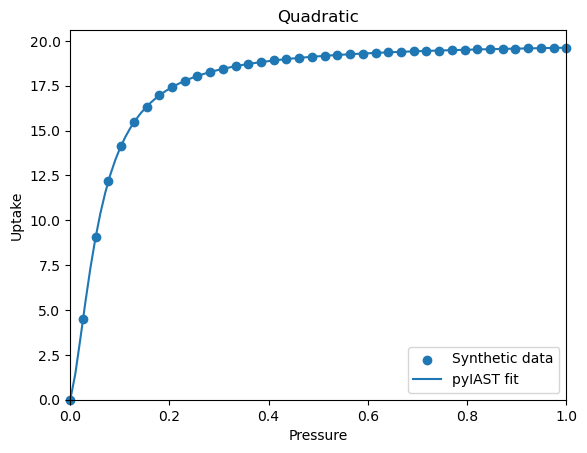

Testing model: BET
BET identified model parameters:
	M = 10.000000
	Ka = 10.000000
	Kb = 0.200000
('RMSE = ', 1.5188956290277306e-13)


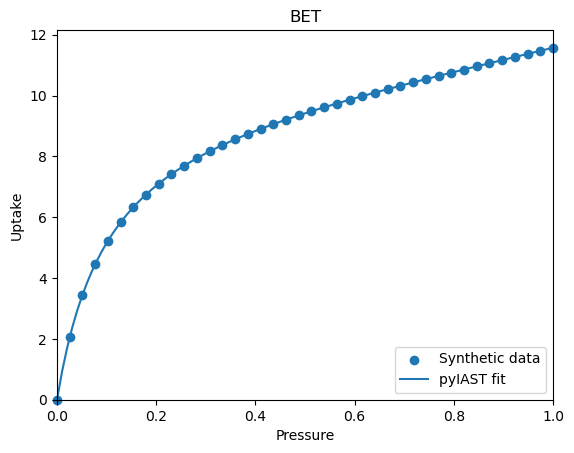

Testing model: Henry
Henry identified model parameters:
	KH = 10.000000
('RMSE = ', 0.0)


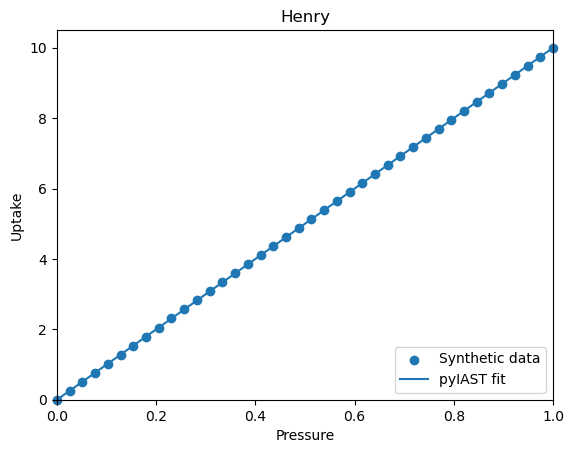

Testing model: TemkinApprox
TemkinApprox identified model parameters:
	M = 10.000000
	K = 10.000000
	theta = -0.100000
('RMSE = ', 3.5834664572366427e-12)


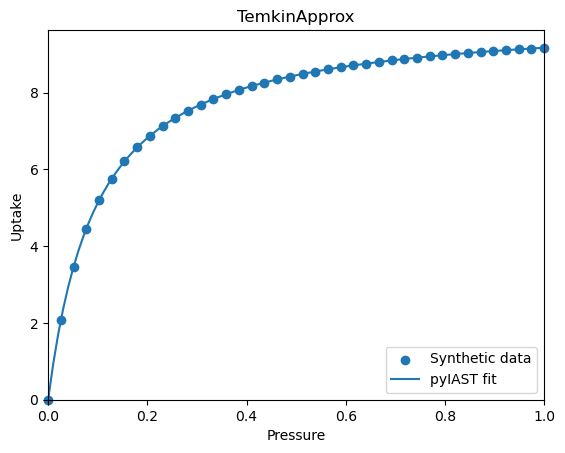

Testing model: DSLangmuir
DSLangmuir identified model parameters:
	M1 = 18.629224
	K1 = 7.111899
	M2 = 17.662691
	K2 = 63.672955
('RMSE = ', 0.2078758635578487)


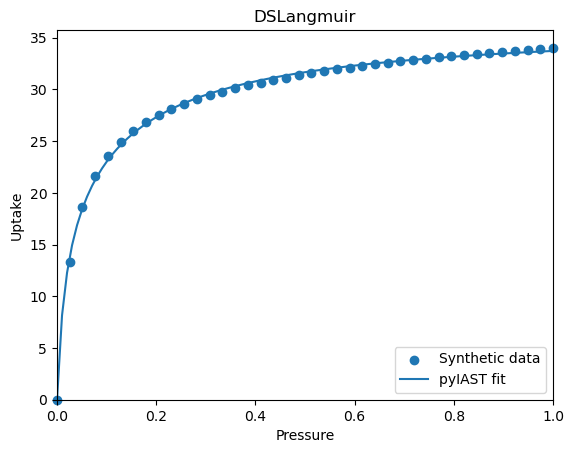

parameters do not match closely in DSLangmuir: 18.629223798108505 instead of 10.0
parameters do not match closely in DSLangmuir: 7.111898670753834 instead of 1.0
parameters do not match closely in DSLangmuir: 17.66269085009939 instead of 30.0
parameters do not match closely in DSLangmuir: 63.6729548290203 instead of 30.0
Testing model: Freundlich


TypeError: reduction operation 'argmin' not allowed for this dtype

In [5]:
for model in models:
    print("Testing model:", model)

    # Generate synthetic data
    df = pd.DataFrame()
    df['P'] = np.linspace(0, 1, 40)
    df['L'] = loading(df['P'], model)

    # use pyIAST to fit model to data
    isotherm = pyiast.ModelIsotherm.initialize_from_df(df, pressure_key='P', loading_key='L',
                                    model=model)
    isotherm.print_params()

    # plot fit
    P_plot = np.linspace(0, 1, 100)

    fig = plt.figure()
    plt.scatter(df['P'], df['L'], label='Synthetic data', clip_on=False)
    plt.plot(P_plot, isotherm.loading(P_plot), label='pyIAST fit')
    plt.xlim([0, 1])
    plt.ylim(ymin=0)
    plt.xlabel('Pressure')
    plt.ylabel('Uptake')
    plt.title(model)
    plt.legend(loc='lower right')
    plt.show()

    # assert parameters are equal
    for param in isotherm.params.keys():
        try:
            np.testing.assert_almost_equal(isotherm.params[param],
                                        model_params[model][param],
                                        decimal=3)
        except AssertionError:
            print(f"parameters do not match closely in {model}: {isotherm.params[param]} instead of {model_params[model][param]}")

### Quick visual test on the Interpolator isotherm

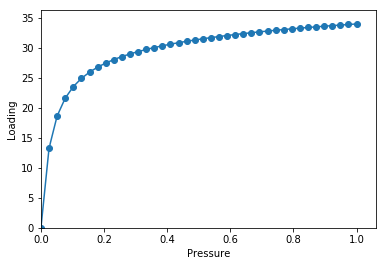

In [ ]:
isotherm = pyiast.InterpolatorIsotherm(df, pressure_key='P', loading_key='L')
pyiast.plot_isotherm(isotherm)

### You can also use the isotherm to calculate the pressure based on the loading
This is an 'inverted' isotherm. 
**This is only supported for Freundlich isotherms at the moment**

isotherm is pyi

In [9]:
isotherm = pyiast.ModelIsotherm('Freundlich', dict(K=10, n_inv=0.5))
test_pressures = np.array([0.3,3.,30.])
predicted_pressures=isotherm.pressure(isotherm.loading(test_pressures))
np.testing.assert_almost_equal(test_pressures, predicted_pressures)